# Evaluation — CliffWalking-v1
### DQN baseline · PPO baseline · DQN+Precedence (C1/C2/C3) · PPO+Precedence (C1/C2/C3)

CliffWalking requires **richer metrics than CartPole** because reward alone
is insufficient — an agent can get a high reward by standing still (−1/step,
no cliff, no goal). The full picture needs:

| Metric | What it tells us |
|---|---|
| **Mean ± std reward** (100 greedy eps) | Final performance — primary paper number |
| **Cliff rate** — % episodes hitting cliff | Safety of learned policy |
| **Goal rate** — % episodes reaching goal | Task completion |
| **Steps-to-goal** — mean steps in goal eps | Path efficiency (optimal = 13) |
| **Episodes to solve** (mean-25 ≥ −20) | Sample efficiency |
| **Training stability** (std last 50 eps) | Consistency of training |
| **Robustness** — action noise σ ∈ {0.05,0.1,0.2} | Policy robustness |
| **Grid heatmap** — visited cells under greedy | Visualise learned path |
| **Summary table** | Paper-ready comparison |

> **Robustness for CliffWalking:** We inject noise into the *action selection*  
> (ε-random override) rather than observation noise, because the one-hot  
> discrete state has no meaningful continuous perturbation.  
> ε ∈ {0.0, 0.05, 0.10, 0.20} fraction of steps → random action.

## 1. Imports & Paths

In [34]:
import os, json, random
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
from gymnasium.wrappers import TimeLimit
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Paths — adjust to your folder structure ──────────────────────────────────
BASE_DIR = ".."

# Baseline checkpoints
DQN_BASELINE_PTH = os.path.join(BASE_DIR, "DQN_plots/CliffWalking-v1/dqn_agent.pth")
PPO_BASELINE_PTH = os.path.join(BASE_DIR, "PPO_plots/CliffWalking-v1/ppo_agent.pth")

# Precedence checkpoints
DQN_PREC_DIR = os.path.join(BASE_DIR, "world_model/checkpoints_dqn_precedence_CliffWalking")
PPO_PREC_DIR = os.path.join(BASE_DIR, "world_model/checkpoints_ppo_precedence_CliffWalking")

# Training history JSONs
DQN_BASELINE_JSON = os.path.join(BASE_DIR, "DQN_plots/CliffWalking-v1/dqn_metrics.json")
PPO_BASELINE_JSON = os.path.join(BASE_DIR, "PPO_plots/CliffWalking-v1/ppo_metrics.json")
DQN_PREC_JSON     = os.path.join(DQN_PREC_DIR, "dqn_precedence_cliffwalking_results.json")
PPO_PREC_JSON     = os.path.join(PPO_PREC_DIR, "ppo_precedence_cliffwalking_results.json")

# Evaluation settings
ENV_NAME         = "CliffWalking-v1"
MAX_STEPS_PER_EP = 200          # same cap used in training
N_EVAL_EPS       = 100          # greedy episodes for final performance
N_ROBUST_EPS     = 50           # episodes per noise level
ACTION_EPS_LEVELS = [0.0, 0.05, 0.10, 0.20]  # random-action override rates
SOLVE_THRESH     = -20.0        # mean-25 ≥ −20 → agent is learning to reach goal
OPTIMAL_REWARD   = -13.0        # shortest path reward

# Grid constants (must match training)
GRID_ROWS  = 4
GRID_COLS  = 12
N_STATES   = 48
N_ACTIONS  = 4
CLIFF_CELLS = set(range(37, 47))
GOAL_CELL   = 47
START_CELL  = 36

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PLOT_DIR = "eval_plots_CliffWalking"
os.makedirs(PLOT_DIR, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f"✅ Setup OK  |  device={DEVICE}  |  eval_eps={N_EVAL_EPS}")
print(f"  Cliff cells   : {sorted(CLIFF_CELLS)}")
print(f"  Optimal reward: {OPTIMAL_REWARD} ({13} steps)")
print(f"  Solve thresh  : mean-25 ≥ {SOLVE_THRESH}")
print(f"  Action ε levels: {ACTION_EPS_LEVELS}")


✅ Setup OK  |  device=cpu  |  eval_eps=100
  Cliff cells   : [37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
  Optimal reward: -13.0 (13 steps)
  Solve thresh  : mean-25 ≥ -20.0
  Action ε levels: [0.0, 0.05, 0.1, 0.2]


## 2. Network Definitions 

In [35]:
# ── Helpers ────────────────────────────────────────────────────────────────────
def state_to_rc(s):
    return divmod(int(s), GRID_COLS)

def one_hot_state(s, n=N_STATES):
    oh = np.zeros(n, dtype=np.float32)
    oh[int(s)] = 1.0
    return oh

def apply_action(s, a):
    """Exact CliffWalking physics — used in path analysis."""
    r, c = state_to_rc(s)
    if   a == 0: nr, nc = max(0, r-1), c
    elif a == 1: nr, nc = r, min(GRID_COLS-1, c+1)
    elif a == 2: nr, nc = min(GRID_ROWS-1, r+1), c
    else:        nr, nc = r, max(0, c-1)
    return nr * GRID_COLS + nc

# ── DQN Q-Network (hidden=128, one-hot input 48D) ─────────────────────────────
class QNetwork(nn.Module):
    """Matches dqn_precedence_CliffWalking.ipynb — hidden=128, ReLU."""
    def __init__(self, state_dim=N_STATES, n_actions=N_ACTIONS, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden,    hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )
    def forward(self, x): return self.net(x)

# ── PPO Actor (hidden=(64,64), Tanh, one-hot input 48D) ───────────────────────
def build_mlp_tanh(in_dim, hidden_sizes, out_dim):
    layers, prev = [], in_dim
    for h in hidden_sizes:
        layers += [nn.Linear(prev, h), nn.Tanh()]
        prev = h
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

class Actor(nn.Module):
    """Matches ppo_precedence_CliffWalking.ipynb — hidden=(64,64), Tanh."""
    def __init__(self, obs_dim=N_STATES, n_act=N_ACTIONS, hidden=(64,64)):
        super().__init__()
        self.net = build_mlp_tanh(obs_dim, hidden, n_act)
    def forward(self, x): return self.net(x)

print("✅ Network classes defined")
print(f"  QNetwork : Linear(48→128)→ReLU→Linear(128→128)→ReLU→Linear(128→4)")
print(f"  Actor    : Linear(48→64)→Tanh→Linear(64→64)→Tanh→Linear(64→4)")


✅ Network classes defined
  QNetwork : Linear(48→128)→ReLU→Linear(128→128)→ReLU→Linear(128→4)
  Actor    : Linear(48→64)→Tanh→Linear(64→64)→Tanh→Linear(64→4)


## 3. Load All Agents

In [36]:
def load_dqn(path):
    ckpt   = torch.load(path, map_location=DEVICE, weights_only=False)
    sd     = ckpt.get("q_net", ckpt) if isinstance(ckpt, dict) else ckpt
    hidden = sd["net.0.weight"].shape[0]   # infer from checkpoint
    net    = QNetwork(hidden=hidden).to(DEVICE)
    net.load_state_dict(sd)
    net.eval()
    print(f"    [DQN] hidden={hidden}")
    return net

def load_ppo(path):
    net = Actor().to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    sd = ckpt.get("actor", ckpt) if isinstance(ckpt, dict) else ckpt
    net.load_state_dict(sd)
    net.eval()
    return net

agents = {}   # name → (net, type)  type ∈ {'dqn','ppo'}

# Baselines
for label, path, loader, atype in [
    ("DQN baseline", DQN_BASELINE_PTH, load_dqn, "dqn"),
    ("PPO baseline", PPO_BASELINE_PTH, load_ppo, "ppo"),
]:
    if os.path.exists(path):
        agents[label] = (loader(path), atype)
        print(f"✅ {label} loaded")
    else:
        print(f"⚠️  Not found: {path}")

# DQN + Precedence
for cfg in [1, 2, 3]:
    path = os.path.join(DQN_PREC_DIR, f"dqn_config{cfg}.pth")
    if os.path.exists(path):
        agents[f"DQN+Prec C{cfg}"] = (load_dqn(path), "dqn")
        print(f"✅ DQN+Prec Config {cfg} loaded")
    else:
        print(f"⚠️  Not found: {path}")

# PPO + Precedence
for cfg in [1, 2, 3]:
    path = os.path.join(PPO_PREC_DIR, f"ppo_config{cfg}.pth")
    if os.path.exists(path):
        agents[f"PPO+Prec C{cfg}"] = (load_ppo(path), "ppo")
        print(f"✅ PPO+Prec Config {cfg} loaded")
    else:
        print(f"⚠️  Not found: {path}")

print(f"\n📦 {len(agents)} agents loaded: {list(agents.keys())}")


    [DQN] hidden=64
✅ DQN baseline loaded
✅ PPO baseline loaded
    [DQN] hidden=128
✅ DQN+Prec Config 1 loaded
    [DQN] hidden=128
✅ DQN+Prec Config 2 loaded
    [DQN] hidden=128
✅ DQN+Prec Config 3 loaded
✅ PPO+Prec Config 1 loaded
✅ PPO+Prec Config 2 loaded
✅ PPO+Prec Config 3 loaded

📦 8 agents loaded: ['DQN baseline', 'PPO baseline', 'DQN+Prec C1', 'DQN+Prec C2', 'DQN+Prec C3', 'PPO+Prec C1', 'PPO+Prec C2', 'PPO+Prec C3']


## 4. Evaluation Function

Returns per-episode: reward, cliff flag, goal flag, steps, path taken.

**Robustness:** ε-random override — at each step, with probability ε the agent
takes a random action instead of its greedy choice. This simulates execution
noise / actuator failures, which is more meaningful than obs noise for a
discrete grid world.

In [37]:
@torch.no_grad()
def select_action(net, s_oh: np.ndarray, agent_type: str) -> int:
    """Greedy: DQN argmax Q  |  PPO argmax logits (no sampling at eval)."""
    t = torch.FloatTensor(s_oh).unsqueeze(0).to(DEVICE)
    return int(net(t).argmax(dim=-1).item())


def run_episodes(net, agent_type: str,
                 n_eps: int = N_EVAL_EPS,
                 action_eps: float = 0.0,
                 seed_offset: int = 0) -> dict:
    """
    Run n_eps episodes.

    Parameters
    ----------
    action_eps : probability of random-action override per step
                 (0.0 = pure greedy, 0.2 = 20% random)

    Returns
    -------
    dict with lists: rewards, cliff_flags, goal_flags, steps, paths
    """
    env = gym.make(ENV_NAME)
    env = TimeLimit(env, max_episode_steps=MAX_STEPS_PER_EP)

    rewards, cliff_flags, goal_flags, steps_list, paths = [], [], [], [], []

    for ep in range(n_eps):
        s, _ = env.reset(seed=SEED + seed_offset + ep)
        ep_r, done  = 0.0, False
        fell_cliff  = False
        reached_goal= False
        ep_steps    = 0
        path        = [s]

        while not done:
            s_oh = one_hot_state(s)

            if action_eps > 0 and random.random() < action_eps:
                a = random.randint(0, N_ACTIONS - 1)
            else:
                a = select_action(net, s_oh, agent_type)

            s_next, r, term, trunc, _ = env.step(a)
            done      = term or trunc
            ep_r     += r
            ep_steps += 1

            # Theoretical next cell (before gym cliff-reset)
            theo = apply_action(s, a)
            if r == -100 and int(theo) in CLIFF_CELLS:
                fell_cliff = True
                path.append(theo)
            else:
                path.append(s_next)
                if s_next == GOAL_CELL:
                    reached_goal = True

            s = s_next

        rewards.append(ep_r)
        cliff_flags.append(int(fell_cliff))
        goal_flags.append(int(reached_goal))
        steps_list.append(ep_steps)
        paths.append(path)

    env.close()
    return {
        'rewards'    : rewards,
        'cliff_flags': cliff_flags,
        'goal_flags' : goal_flags,
        'steps'      : steps_list,
        'paths'      : paths,
    }

print("✅ Evaluation function defined")


✅ Evaluation function defined


## 5. Metric: Final Performance (100 greedy episodes)

In [38]:
print(f"\n{'='*70}")
print(f"  FINAL PERFORMANCE — {N_EVAL_EPS} greedy episodes (no action noise)")
print(f"  Optimal reward = {OPTIMAL_REWARD}  |  Solve threshold = {SOLVE_THRESH}")
print(f"{'='*70}\n")

perf_results = {}

for name, (net, atype) in agents.items():
    res = run_episodes(net, atype, n_eps=N_EVAL_EPS,
                       action_eps=0.0, seed_offset=1000)

    rw  = res['rewards']
    clf = res['cliff_flags']
    gl  = res['goal_flags']
    st  = res['steps']
    pth = res['paths']

    goal_steps = [st[i] for i in range(len(gl)) if gl[i]]

    perf_results[name] = {
        'rewards'       : rw,
        'cliff_flags'   : clf,
        'goal_flags'    : gl,
        'steps'         : st,
        'paths'         : pth,
        'mean_reward'   : float(np.mean(rw)),
        'std_reward'    : float(np.std(rw)),
        'min_reward'    : float(np.min(rw)),
        'max_reward'    : float(np.max(rw)),
        'cliff_rate'    : float(np.mean(clf)),
        'goal_rate'     : float(np.mean(gl)),
        'avg_steps'     : float(np.mean(st)),
        'avg_steps_goal': float(np.mean(goal_steps)) if goal_steps else float('nan'),
        'n_goal_eps'    : int(sum(gl)),
    }

    print(f"  {name:<20}  "
          f"R={np.mean(rw):7.2f}±{np.std(rw):5.1f}  "
          f"cliff={100*np.mean(clf):5.1f}%  "
          f"goal={100*np.mean(gl):5.1f}%  "
          f"steps_to_goal={np.mean(goal_steps):.1f}" if goal_steps
          else f"  {name:<20}  "
               f"R={np.mean(rw):7.2f}±{np.std(rw):5.1f}  "
               f"cliff={100*np.mean(clf):5.1f}%  "
               f"goal={100*np.mean(gl):5.1f}%  "
               f"steps_to_goal=N/A")


  FINAL PERFORMANCE — 100 greedy episodes (no action noise)
  Optimal reward = -13.0  |  Solve threshold = -20.0

  DQN baseline          R= -15.00±  0.0  cliff=  0.0%  goal=100.0%  steps_to_goal=15.0
  PPO baseline          R= -13.00±  0.0  cliff=  0.0%  goal=100.0%  steps_to_goal=13.0
  DQN+Prec C1           R= -13.00±  0.0  cliff=  0.0%  goal=100.0%  steps_to_goal=13.0
  DQN+Prec C2           R= -13.00±  0.0  cliff=  0.0%  goal=100.0%  steps_to_goal=13.0
  DQN+Prec C3           R= -13.00±  0.0  cliff=  0.0%  goal=100.0%  steps_to_goal=13.0
  PPO+Prec C1           R=-20000.00±  0.0  cliff=100.0%  goal=  0.0%  steps_to_goal=N/A
  PPO+Prec C2           R= -13.00±  0.0  cliff=  0.0%  goal=100.0%  steps_to_goal=13.0
  PPO+Prec C3           R=-20000.00±  0.0  cliff=100.0%  goal=  0.0%  steps_to_goal=N/A


## 6. Metric: Sample Efficiency (episodes to solve)

In [39]:
def episodes_to_solve(rewards_history: list,
                      threshold: float = SOLVE_THRESH,
                      window: int = 25) -> int:
    """First episode where mean-{window} >= threshold. −1 = never solved."""
    rw = np.array(rewards_history)
    for i in range(window - 1, len(rw)):
        if np.mean(rw[i - window + 1 : i + 1]) >= threshold:
            return i + 1
    return -1


def load_history(json_path: str, key: str = None) -> list:
    """
    Load reward history from JSON. Handles multiple formats:
    - Baseline format (new): {"all_episode_rewards": [...]}
    - Baseline format (old): {"train": {"rewards": [...]}}
    - Precedence format: {"config_1": {"rewards": [...]}}
    - Flat list: [reward1, reward2, ...]
    """
    if not os.path.exists(json_path):
        return []
    with open(json_path) as f:
        data = json.load(f)
    if key:
        return data.get(key, {}).get("rewards", [])
    if isinstance(data, list):
        return data
    # New baseline format: top-level "all_episode_rewards"
    if "all_episode_rewards" in data:
        return data.get("all_episode_rewards", [])
    # Old baseline format: nested under "train"
    if "train" in data:
        train_data = data["train"]
        for key_name in ["episode_rewards", "rewards", "train_rewards"]:
            if key_name in train_data:
                return train_data[key_name]
    # Fallback: check for top-level "rewards" key
    if "rewards" in data:
        return data.get("rewards", [])
    return []


print(f"\n{'='*70}")
print(f"  SAMPLE EFFICIENCY — first episode with mean-25 ≥ {SOLVE_THRESH}")
print(f"{'='*70}\n")

histories = {}

# Baselines
for label, json_path in [("DQN baseline", DQN_BASELINE_JSON),
                          ("PPO baseline", PPO_BASELINE_JSON)]:
    h = load_history(json_path)
    if h:
        histories[label] = h
    else:
        print(f"  ⚠️  No training JSON for {label} — add a save step to that notebook")

# Precedence results (both DQN and PPO)
for json_path, prefix in [(DQN_PREC_JSON, "DQN+Prec"),
                           (PPO_PREC_JSON, "PPO+Prec")]:
    if os.path.exists(json_path):
        with open(json_path) as f:
            data = json.load(f)
        for cfg_key, cfg_data in data.items():
            cfg_num = cfg_key.split("_")[-1]
            label   = f"{prefix} C{cfg_num}"
            histories[label] = cfg_data.get("rewards", [])
    else:
        print(f"  ⚠️  Not found: {json_path}")

solve_results = {}
for name, h in histories.items():
    ep = episodes_to_solve(h)
    solve_results[name] = ep
    tag = f"ep {ep:4d}" if ep > 0 else "never  "
    print(f"  {name:<20}  solved at: {tag}  (history: {len(h)} eps)")


  SAMPLE EFFICIENCY — first episode with mean-25 ≥ -20.0

  DQN baseline          solved at: ep   99  (history: 500 eps)
  PPO baseline          solved at: ep  733  (history: 7402 eps)
  DQN+Prec C1           solved at: never    (history: 600 eps)
  DQN+Prec C2           solved at: ep  333  (history: 600 eps)
  DQN+Prec C3           solved at: ep  288  (history: 600 eps)
  PPO+Prec C1           solved at: ep 1137  (history: 19274 eps)
  PPO+Prec C2           solved at: ep 1185  (history: 17658 eps)
  PPO+Prec C3           solved at: ep 2078  (history: 4472 eps)


## 7. Metric: Training Stability (std of last 50 training episodes)

In [40]:
print(f"\n{'='*70}")
print(f"  TRAINING STABILITY — std and mean of reward over last 50 training eps")
print(f"{'='*70}\n")

stability_results = {}
for name, h in histories.items():
    if len(h) >= 50:
        m = float(np.mean(h[-50:]))
        s = float(np.std(h[-50:]))
        stability_results[name] = {'mean': m, 'std': s}
        print(f"  {name:<20}  mean={m:8.2f}  std={s:6.2f}")
    else:
        print(f"  {name:<20}  insufficient history ({len(h)} eps)")



  TRAINING STABILITY — std and mean of reward over last 50 training eps

  DQN baseline          mean=  -15.16  std=  0.50
  PPO baseline          mean=  -12.88  std=  0.84
  DQN+Prec C1           mean= -123.06  std= 76.52
  DQN+Prec C2           mean=  -16.26  std= 14.78
  DQN+Prec C3           mean=  -14.10  std=  1.30
  PPO+Prec C1           mean=  -13.28  std=  1.20
  PPO+Prec C2           mean=  -13.00  std=  0.69
  PPO+Prec C3           mean=  -15.54  std=  1.06


## 8. Metric: Robustness under Action Noise

At each step, with probability ε the greedy action is replaced by a random one.
This simulates actuator noise / stochastic execution in a discrete grid world.

Key question: do Precedence-guided agents recover more gracefully when pushed
off their learned path by a random action?

In [41]:
print(f"\n{'='*70}")
print(f"  ROBUSTNESS — {N_ROBUST_EPS} eps per action-ε level {ACTION_EPS_LEVELS}")
print(f"{'='*70}\n")

robustness_results = {}

for name, (net, atype) in agents.items():
    robustness_results[name] = {}
    row = f"  {name:<20}"
    for eps_val in ACTION_EPS_LEVELS:
        res = run_episodes(net, atype, n_eps=N_ROBUST_EPS,
                           action_eps=eps_val, seed_offset=3000)
        m_r   = float(np.mean(res['rewards']))
        m_clf = float(np.mean(res['cliff_flags']))
        m_gl  = float(np.mean(res['goal_flags']))
        robustness_results[name][eps_val] = {
            'mean_reward' : m_r,
            'cliff_rate'  : m_clf,
            'goal_rate'   : m_gl,
        }
        row += f"  ε={eps_val:.2f}→R={m_r:6.1f}(cliff={100*m_clf:.0f}%)"
    print(row)



  ROBUSTNESS — 50 eps per action-ε level [0.0, 0.05, 0.1, 0.2]

  DQN baseline          ε=0.00→R= -15.0(cliff=0%)  ε=0.05→R= -15.9(cliff=0%)  ε=0.10→R= -19.8(cliff=2%)  ε=0.20→R= -37.9(cliff=16%)
  PPO baseline          ε=0.00→R= -13.0(cliff=0%)  ε=0.05→R= -35.1(cliff=20%)  ε=0.10→R= -42.0(cliff=20%)  ε=0.20→R=-112.7(cliff=52%)
  DQN+Prec C1           ε=0.00→R= -13.0(cliff=0%)  ε=0.05→R= -24.5(cliff=10%)  ε=0.10→R= -38.0(cliff=22%)  ε=0.20→R=-140.2(cliff=58%)
  DQN+Prec C2           ε=0.00→R= -13.0(cliff=0%)  ε=0.05→R= -39.5(cliff=20%)  ε=0.10→R= -46.3(cliff=24%)  ε=0.20→R= -96.3(cliff=46%)
  DQN+Prec C3           ε=0.00→R= -13.0(cliff=0%)  ε=0.05→R= -24.6(cliff=10%)  ε=0.10→R= -59.4(cliff=26%)  ε=0.20→R=-104.4(cliff=44%)
  PPO+Prec C1           ε=0.00→R=-20000.0(cliff=100%)  ε=0.05→R=-7152.8(cliff=98%)  ε=0.10→R=-4805.8(cliff=98%)  ε=0.20→R=-2957.4(cliff=96%)
  PPO+Prec C2           ε=0.00→R= -13.0(cliff=0%)  ε=0.05→R= -30.5(cliff=16%)  ε=0.10→R= -44.6(cliff=22%)  ε=0.20→R=-117.4(cli

## 9. Learning Curve Comparison

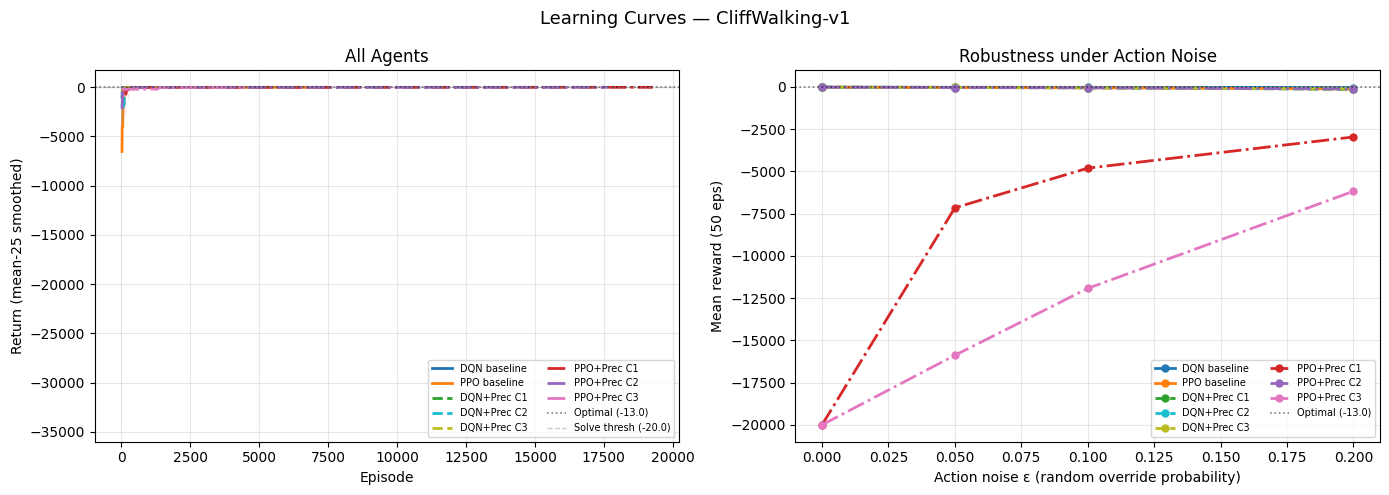

📊 Saved → eval_plots_CliffWalking\cliffwalking_eval_curves.png


In [42]:
COLORS = {
    "DQN baseline" : "#1f77b4",
    "PPO baseline" : "#ff7f0e",
    "DQN+Prec C1"  : "#2ca02c",
    "DQN+Prec C2"  : "#17becf",
    "DQN+Prec C3"  : "#bcbd22",
    "PPO+Prec C1"  : "#d62728",
    "PPO+Prec C2"  : "#9467bd",
    "PPO+Prec C3"  : "#e377c2",
}
LSTYLES = {
    "DQN baseline" : "-",  "PPO baseline" : "-",
    "DQN+Prec C1"  : "--", "DQN+Prec C2"  : "--", "DQN+Prec C3"  : "--",
    "PPO+Prec C1"  : "-.", "PPO+Prec C2"  : "-.", "PPO+Prec C3"  : "-.",
}
WINDOW = 25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Learning Curves — {ENV_NAME}", fontsize=13)

# ── Left: reward curves ────────────────────────────────────────────
ax = axes[0]
for name, h in histories.items():
    if not h:
        continue
    rw  = np.array(h)
    col = COLORS.get(name, "grey")
    sty = LSTYLES.get(name, "-")
    ax.plot(rw, alpha=0.10, color=col, linewidth=0.5)
    if len(rw) >= WINDOW:
        ma = np.convolve(rw, np.ones(WINDOW)/WINDOW, mode='valid')
        ax.plot(np.arange(WINDOW-1, len(rw)), ma,
                color=col, linestyle=sty, linewidth=2.0, label=name)

ax.axhline(OPTIMAL_REWARD, color='k', linestyle=':', alpha=0.5,
           linewidth=1.2, label=f"Optimal ({OPTIMAL_REWARD})")
ax.axhline(SOLVE_THRESH, color='grey', linestyle='--', alpha=0.4,
           linewidth=1, label=f"Solve thresh ({SOLVE_THRESH})")
ax.set_xlabel("Episode"); ax.set_ylabel("Return (mean-25 smoothed)")
ax.set_title("All Agents"); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

# ── Right: robustness — mean reward vs action ε ───────────────────
ax = axes[1]
for name, noise_dict in robustness_results.items():
    eps_vals = sorted(noise_dict.keys())
    means    = [noise_dict[e]['mean_reward'] for e in eps_vals]
    col      = COLORS.get(name, "grey")
    sty      = LSTYLES.get(name, "-")
    ax.plot(eps_vals, means, color=col, linestyle=sty,
            linewidth=2.0, marker='o', markersize=5, label=name)

ax.axhline(OPTIMAL_REWARD, color='k', linestyle=':', alpha=0.5,
           linewidth=1.2, label=f"Optimal ({OPTIMAL_REWARD})")
ax.set_xlabel("Action noise ε (random override probability)")
ax.set_ylabel("Mean reward (50 eps)")
ax.set_title("Robustness under Action Noise")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(PLOT_DIR, "cliffwalking_eval_curves.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Saved → {fig_path}")


## 10. Reward & Cliff/Goal Rate — Bar Charts

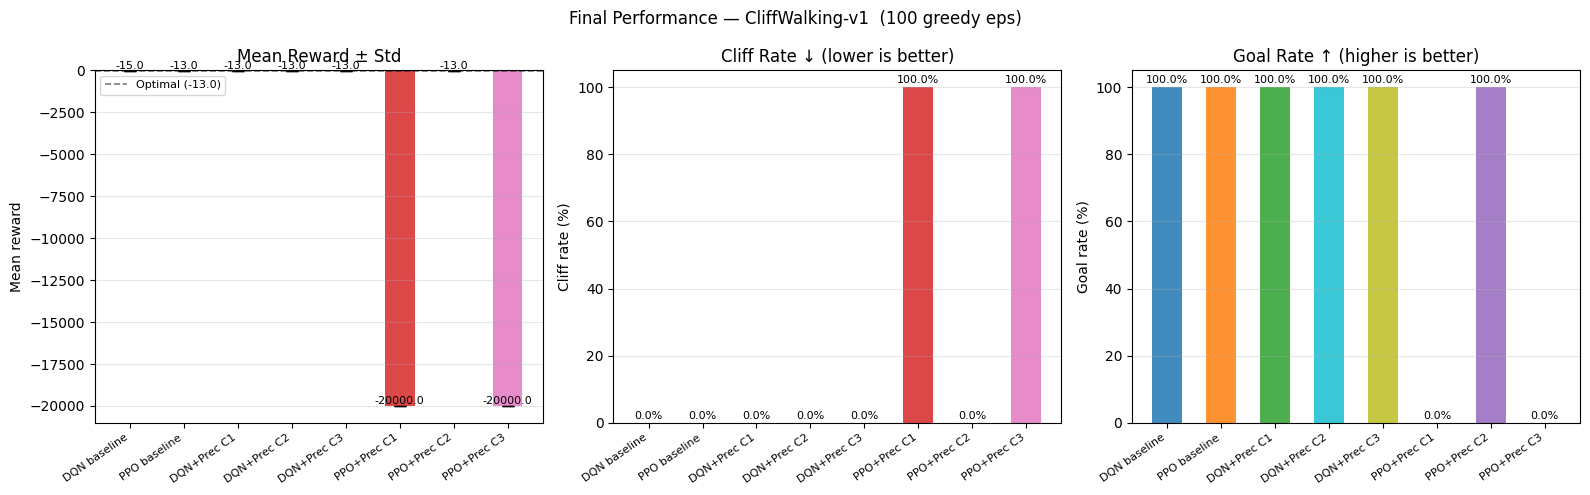

📊 Saved → eval_plots_CliffWalking\cliffwalking_perf_bars.png


In [43]:
names_list = list(perf_results.keys())
mean_r     = [perf_results[n]['mean_reward']  for n in names_list]
std_r      = [perf_results[n]['std_reward']   for n in names_list]
cliff_pct  = [100*perf_results[n]['cliff_rate'] for n in names_list]
goal_pct   = [100*perf_results[n]['goal_rate']  for n in names_list]
col_list   = [COLORS.get(n, '#aaaaaa') for n in names_list]
x          = np.arange(len(names_list))
w          = 0.55

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Final Performance — {ENV_NAME}  ({N_EVAL_EPS} greedy eps)", fontsize=12)

# Mean reward
ax = axes[0]
bars = ax.bar(x, mean_r, width=w, color=col_list, yerr=std_r,
              capsize=4, alpha=0.85)
for bar, val in zip(bars, mean_r):
    offset = 1 if val >= 0 else -4
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f"{val:.1f}", ha='center', va='bottom', fontsize=8)
ax.axhline(OPTIMAL_REWARD, color='k', linestyle='--', alpha=0.5,
           linewidth=1.2, label=f"Optimal ({OPTIMAL_REWARD})")
ax.set_xticks(x); ax.set_xticklabels(names_list, rotation=35, ha='right', fontsize=8)
ax.set_ylabel("Mean reward"); ax.set_title("Mean Reward ± Std")
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Cliff rate
ax = axes[1]
bars = ax.bar(x, cliff_pct, width=w, color=col_list, alpha=0.85)
for bar, val in zip(bars, cliff_pct):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val:.1f}%", ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names_list, rotation=35, ha='right', fontsize=8)
ax.set_ylabel("Cliff rate (%)"); ax.set_title("Cliff Rate ↓ (lower is better)")
ax.grid(axis='y', alpha=0.3)

# Goal rate
ax = axes[2]
bars = ax.bar(x, goal_pct, width=w, color=col_list, alpha=0.85)
for bar, val in zip(bars, goal_pct):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val:.1f}%", ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names_list, rotation=35, ha='right', fontsize=8)
ax.set_ylabel("Goal rate (%)"); ax.set_title("Goal Rate ↑ (higher is better)")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(PLOT_DIR, "cliffwalking_perf_bars.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Saved → {fig_path}")


## 11. Steps-to-Goal Distribution

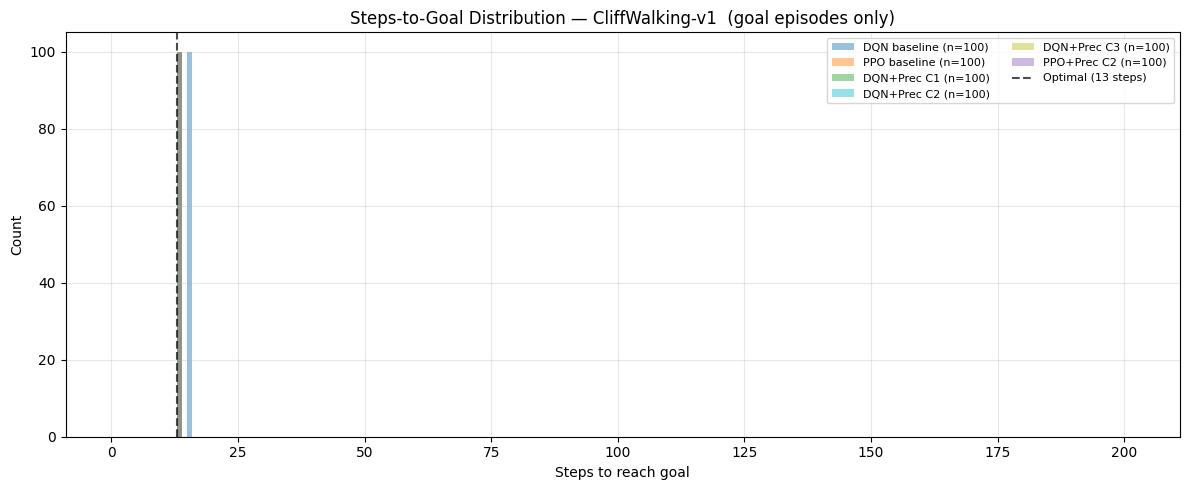

📊 Saved → eval_plots_CliffWalking\cliffwalking_steps_to_goal.png


In [44]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title(f"Steps-to-Goal Distribution — {ENV_NAME}  (goal episodes only)", fontsize=12)

for name in names_list:
    pr = perf_results[name]
    gl = pr['goal_flags']
    st = pr['steps']
    goal_steps = [st[i] for i in range(len(gl)) if gl[i]]
    if goal_steps:
        col = COLORS.get(name, 'grey')
        sty = LSTYLES.get(name, '-')
        ax.hist(goal_steps, bins=range(1, MAX_STEPS_PER_EP+2),
                alpha=0.45, color=col, label=f"{name} (n={len(goal_steps)})")

ax.axvline(13, color='k', linestyle='--', linewidth=1.5,
           label='Optimal (13 steps)', alpha=0.7)
ax.set_xlabel("Steps to reach goal"); ax.set_ylabel("Count")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(PLOT_DIR, "cliffwalking_steps_to_goal.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Saved → {fig_path}")


## 12. Robustness Heatmaps (reward + cliff rate)

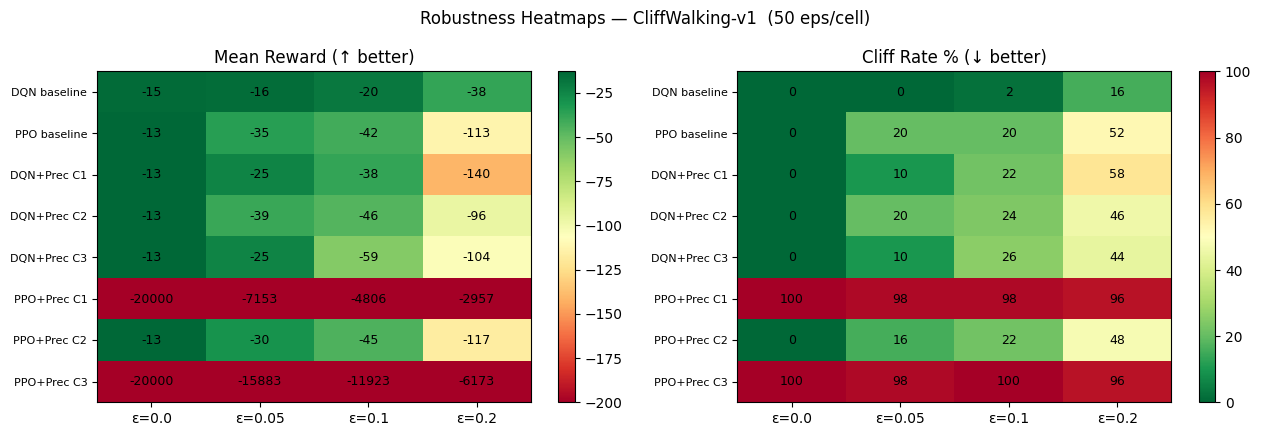

📊 Saved → eval_plots_CliffWalking\cliffwalking_robustness_heatmap.png


In [45]:
eps_vals   = sorted(ACTION_EPS_LEVELS)
n_agents   = len(names_list)

reward_matrix = np.array([
    [robustness_results[n][e]['mean_reward'] for e in eps_vals]
    for n in names_list
])
cliff_matrix = np.array([
    [100*robustness_results[n][e]['cliff_rate'] for e in eps_vals]
    for n in names_list
])

fig, axes = plt.subplots(1, 2, figsize=(13, max(4, n_agents * 0.55)))
fig.suptitle(f"Robustness Heatmaps — {ENV_NAME}  ({N_ROBUST_EPS} eps/cell)", fontsize=12)

for ax, matrix, title, cmap, vmin, vmax, fmt in [
    (axes[0], reward_matrix, "Mean Reward (↑ better)",
     'RdYlGn', -200, OPTIMAL_REWARD, ".0f"),
    (axes[1], cliff_matrix,  "Cliff Rate % (↓ better)",
     'RdYlGn_r', 0, 100, ".0f"),
]:
    im = ax.imshow(matrix, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax)
    for i in range(n_agents):
        for j in range(len(eps_vals)):
            val = matrix[i, j]
            ax.text(j, i, f"{val:{fmt}}",
                    ha='center', va='center', fontsize=9,
                    color='black')
    ax.set_xticks(range(len(eps_vals)))
    ax.set_xticklabels([f"ε={e}" for e in eps_vals])
    ax.set_yticks(range(n_agents))
    ax.set_yticklabels(names_list, fontsize=8)
    ax.set_title(title)

plt.tight_layout()
fig_path = os.path.join(PLOT_DIR, "cliffwalking_robustness_heatmap.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Saved → {fig_path}")


## 13. Grid Heatmaps — Visited Cells under Greedy Policy

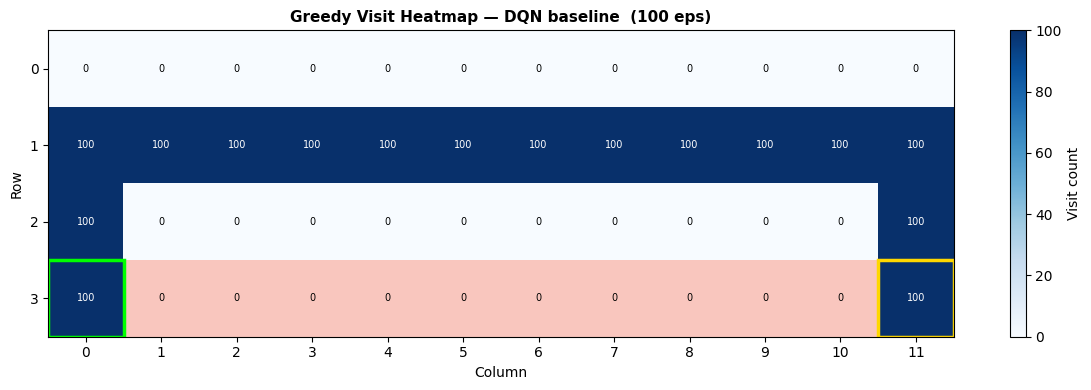

📊 Saved → eval_plots_CliffWalking\heatmap_DQN_baseline.png


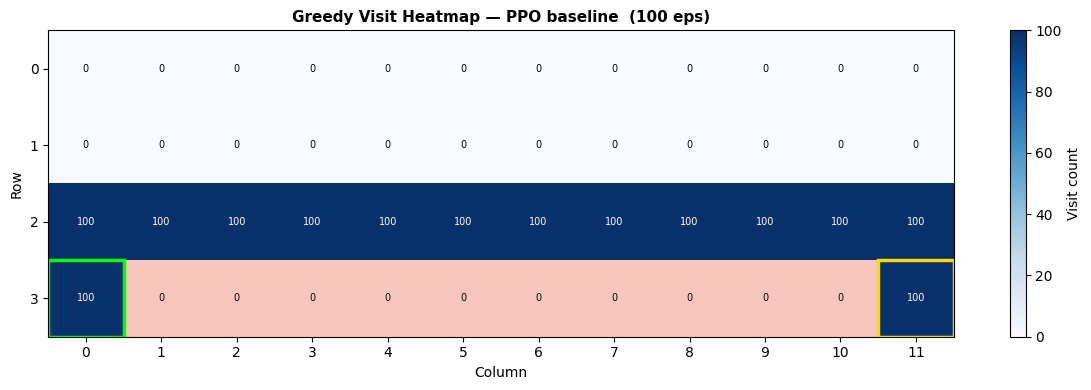

📊 Saved → eval_plots_CliffWalking\heatmap_PPO_baseline.png


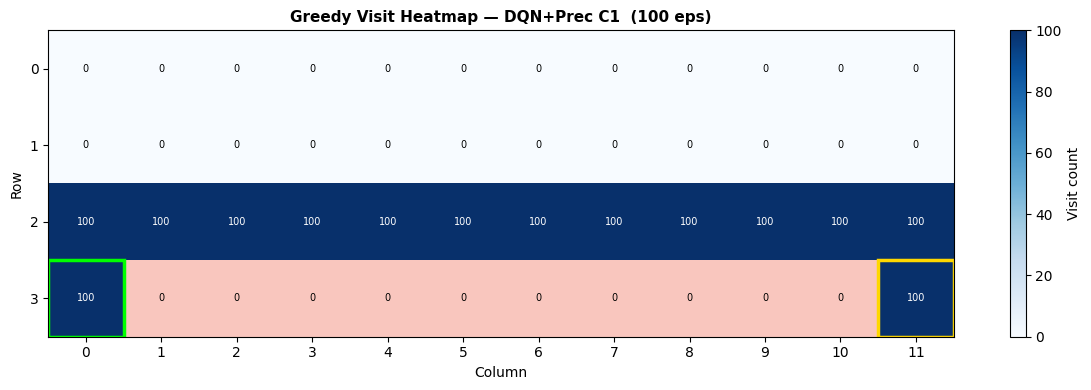

📊 Saved → eval_plots_CliffWalking\heatmap_DQNplusPrec_C1.png


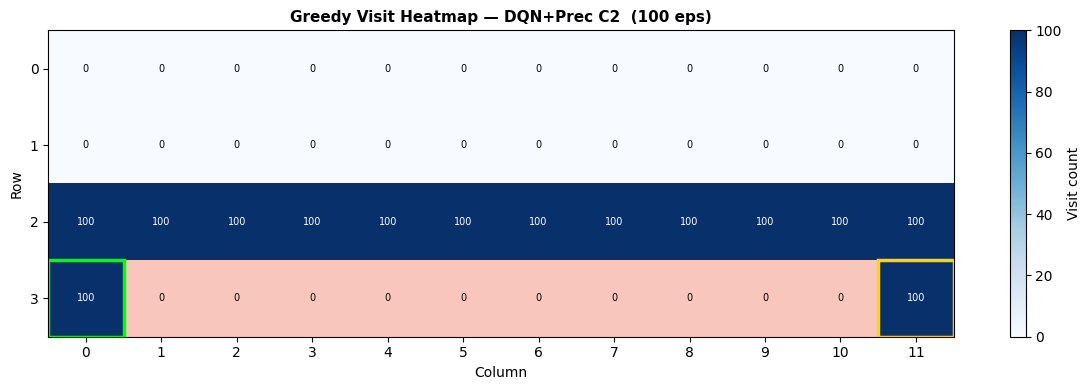

📊 Saved → eval_plots_CliffWalking\heatmap_DQNplusPrec_C2.png


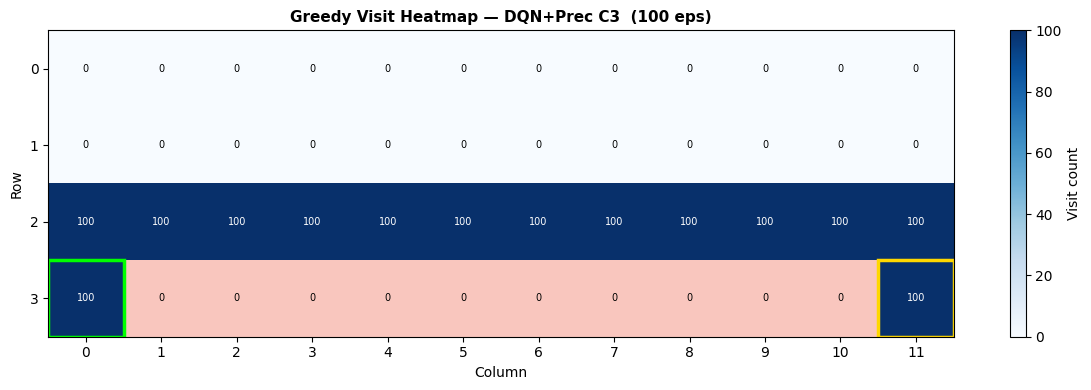

📊 Saved → eval_plots_CliffWalking\heatmap_DQNplusPrec_C3.png


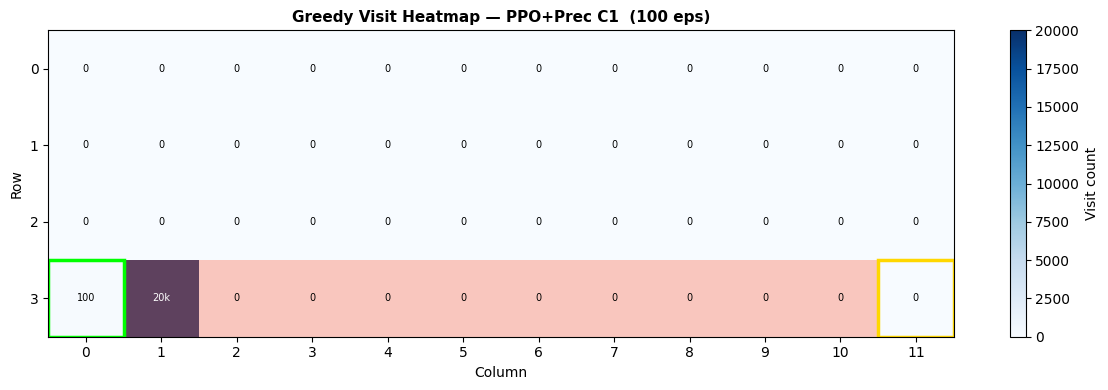

📊 Saved → eval_plots_CliffWalking\heatmap_PPOplusPrec_C1.png


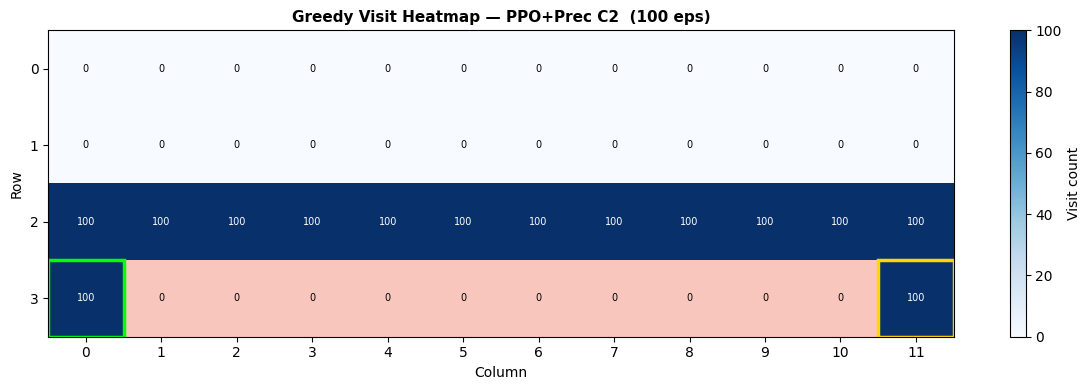

📊 Saved → eval_plots_CliffWalking\heatmap_PPOplusPrec_C2.png


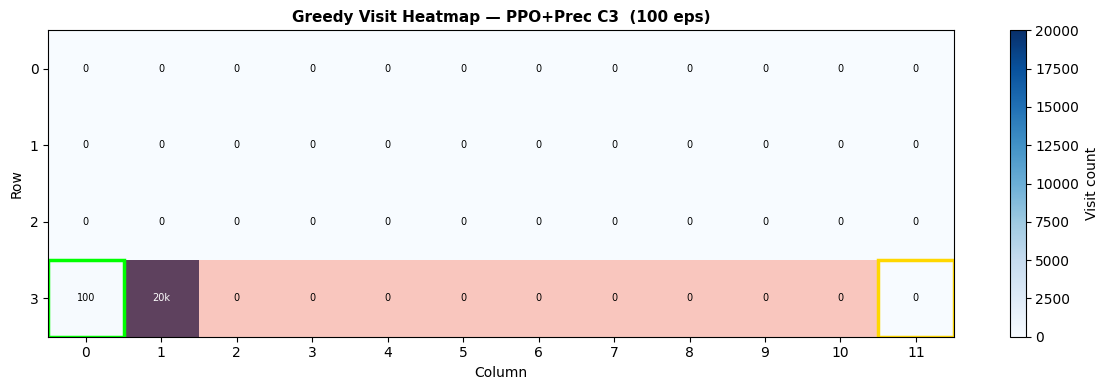

📊 Saved → eval_plots_CliffWalking\heatmap_PPOplusPrec_C3.png


In [46]:
def plot_grid_heatmap(name, paths, save_path):
    """
    Plot 4×12 visit-frequency heatmap from greedy evaluation paths.
    Overlays: cliff (red), start (lime border), goal (gold border).
    """
    visits = np.zeros(N_STATES, dtype=int)
    for path in paths:
        for cell in path:
            if 0 <= int(cell) < N_STATES:
                visits[int(cell)] += 1

    grid = visits.reshape(GRID_ROWS, GRID_COLS)
    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.imshow(grid, cmap='Blues', aspect='auto')
    plt.colorbar(im, ax=ax, label='Visit count')

    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            val = grid[r, c]
            ax.text(c, r, str(val) if val < 10000 else f"{val//1000}k",
                    ha='center', va='center', fontsize=7,
                    color='white' if val > grid.max()*0.6 else 'black')

    # Cliff overlay
    for c in range(1, 11):
        ax.add_patch(mpatches.Rectangle(
            (c-0.5, 2.5), 1, 1, fill=True, facecolor='tomato', alpha=0.35))
    # Start border
    ax.add_patch(mpatches.Rectangle(
        (-0.5, 2.5), 1, 1, fill=False, edgecolor='lime', linewidth=2.5))
    # Goal border
    ax.add_patch(mpatches.Rectangle(
        (10.5, 2.5), 1, 1, fill=False, edgecolor='gold', linewidth=2.5))

    ax.set_title(f"Greedy Visit Heatmap — {name}  ({len(paths)} eps)",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Column'); ax.set_ylabel('Row')
    ax.set_xticks(range(GRID_COLS)); ax.set_yticks(range(GRID_ROWS))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📊 Saved → {save_path}")


for name in names_list:
    paths = perf_results[name]['paths']
    safe_name = name.replace(' ', '_').replace('+', 'plus')
    plot_grid_heatmap(
        name, paths,
        save_path=os.path.join(PLOT_DIR, f"heatmap_{safe_name}.png")
    )


## 14. Summary Table (paper-ready)

In [47]:
rows = []
for name in names_list:
    p  = perf_results[name]
    s  = stability_results.get(name, {})
    ep = solve_results.get(name, None)
    rb = robustness_results.get(name, {})

    goal_steps_all = [p['steps'][i] for i in range(len(p['goal_flags']))
                      if p['goal_flags'][i]]

    rows.append({
        'Agent'                  : name,
        'Mean reward'            : f"{p['mean_reward']:.2f}",
        'Std reward'             : f"{p['std_reward']:.2f}",
        'Cliff rate %'           : f"{100*p['cliff_rate']:.1f}",
        'Goal rate %'            : f"{100*p['goal_rate']:.1f}",
        'Avg steps-to-goal'      : f"{p['avg_steps_goal']:.1f}" if not np.isnan(p['avg_steps_goal']) else "N/A",
        'Goal eps (n)'           : str(p['n_goal_eps']),
        'Train std (last 50)'    : f"{s.get('std', float('nan')):.2f}" if s else "—",
        'Eps to solve'           : (str(ep) if ep and ep > 0 else ("never" if ep == -1 else "—")),
        'Robust ε=0.10 reward'   : f"{rb.get(0.10, {}).get('mean_reward', float('nan')):.1f}",
        'Robust ε=0.10 cliff %'  : f"{100*rb.get(0.10, {}).get('cliff_rate', float('nan')):.1f}",
        'Robust ε=0.20 reward'   : f"{rb.get(0.20, {}).get('mean_reward', float('nan')):.1f}",
    })

df = pd.DataFrame(rows).set_index('Agent')

try:
    from IPython.display import display
    display(df)
except Exception:
    print(df.to_string())

csv_path = os.path.join(PLOT_DIR, "cliffwalking_eval_summary.csv")
df.to_csv(csv_path)
print(f"\n💾 Summary CSV saved → {csv_path}")


,Mean reward,Std reward,Cliff rate %,Goal rate %,Avg steps-to-goal,Goal eps (n),Train std (last 50),Eps to solve,Robust ε=0.10 reward,Robust ε=0.10 cliff %,Robust ε=0.20 reward
Agent,,,,,,,,,,,
DQN baseline,-15.00,0.00,0.0,100.0,15.0,100,0.50,99,-19.8,2.0,-37.9
PPO baseline,-13.00,0.00,0.0,100.0,13.0,100,0.84,733,-42.0,20.0,-112.7
DQN+Prec C1,-13.00,0.00,0.0,100.0,13.0,100,76.52,never,-38.0,22.0,-140.2
DQN+Prec C2,-13.00,0.00,0.0,100.0,13.0,100,14.78,333,-46.3,24.0,-96.3
DQN+Prec C3,-13.00,0.00,0.0,100.0,13.0,100,1.30,288,-59.4,26.0,-104.4
PPO+Prec C1,-20000.00,0.00,100.0,0.0,N/A,0,1.20,1137,-4805.8,98.0,-2957.4
PPO+Prec C2,-13.00,0.00,0.0,100.0,13.0,100,0.69,1185,-44.6,22.0,-117.4
PPO+Prec C3,-20000.00,0.00,100.0,0.0,N/A,0,1.06,2078,-11923.2,100.0,-6172.6



💾 Summary CSV saved → eval_plots_CliffWalking\cliffwalking_eval_summary.csv


## 15. Save All Evaluation Results (JSON)

In [48]:
eval_export = {
    'env'               : ENV_NAME,
    'n_eval_eps'        : N_EVAL_EPS,
    'n_robust_eps'      : N_ROBUST_EPS,
    'solve_threshold'   : SOLVE_THRESH,
    'optimal_reward'    : OPTIMAL_REWARD,
    'action_eps_levels' : ACTION_EPS_LEVELS,
    'performance'       : {
        n: {k: v for k, v in p.items()
            if k not in ('rewards','cliff_flags','goal_flags','steps','paths')}
        for n, p in perf_results.items()
    },
    'sample_efficiency' : solve_results,
    'stability'         : stability_results,
    'robustness'        : {
        n: {str(e): d for e, d in eps_dict.items()}
        for n, eps_dict in robustness_results.items()
    },
}

out_path = os.path.join(PLOT_DIR, "cliffwalking_eval_results.json")
with open(out_path, 'w') as f:
    json.dump(eval_export, f, indent=4)

print(f"✅ Evaluation results saved → {out_path}")
print(f"\n✅ Done! All outputs in: {PLOT_DIR}/")
print(f"  cliffwalking_eval_curves.png")
print(f"  cliffwalking_perf_bars.png")
print(f"  cliffwalking_steps_to_goal.png")
print(f"  cliffwalking_robustness_heatmap.png")
print(f"  heatmap_<agent>.png  (one per agent)")
print(f"  cliffwalking_eval_summary.csv")
print(f"  cliffwalking_eval_results.json")


✅ Evaluation results saved → eval_plots_CliffWalking\cliffwalking_eval_results.json

✅ Done! All outputs in: eval_plots_CliffWalking/
  cliffwalking_eval_curves.png
  cliffwalking_perf_bars.png
  cliffwalking_steps_to_goal.png
  cliffwalking_robustness_heatmap.png
  heatmap_<agent>.png  (one per agent)
  cliffwalking_eval_summary.csv
  cliffwalking_eval_results.json
